# Pipeline 4 — Safehouse Operational Performance Prediction

Predict next-month **incident count** per safehouse so operations staff can
allocate resources proactively across nine facilities.

## 1. Business Understanding

Our nonprofit operates **nine safehouses** providing refuge and rehabilitation
for Native American women and girls who have experienced trafficking and abuse.
A small central team (Operations Director + safehouse supervisors) must decide
each month how to distribute limited counseling, security, and program staff
across these sites.

**Problem:** Staff allocation is currently reactive — resources flow to
whichever safehouse *just had* the most incidents. We want to shift to
**proactive** allocation by predicting next month's incident count for each
safehouse before the month begins.

**Analytic goals:**

| Goal | Type | Question |
|------|------|----------|
| Predictive | Operational planning | How many incidents should we expect at each safehouse next month? |
| Explanatory | Resource allocation strategy | Which operational levers (visitations, process recordings, capacity utilization, donations) are associated with incident frequency? |

**Target variable:** `incident_count` (next month, per safehouse).

**Stakeholders:** Operations Director, individual safehouse supervisors.

**Success criteria:** A model that produces actionable per-safehouse forecasts
with lower error than the naive baseline of "predict last month's count."

## 2. Data Acquisition and Preparation

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path.cwd()
for _ in range(8):
    ml_path = ROOT / 'is455' / 'ml-pipelines'
    if ml_path.exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'is455' / 'ml-pipelines'))

from utils.db_loader import get_engine, load_table
engine = get_engine()
print('Database connection established.')

Database connection established.


In [2]:
# ── Resolve project root and load utilities ───────────────────────────────────
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines').exists():
        break
    ROOT = ROOT.parent

MLPIPELINES = ROOT / 'is455' / 'ml-pipelines'
sys.path.insert(0, str(MLPIPELINES))

from utils.db_loader import get_engine, load_table
from utils.onnx_exporter import export_to_onnx, verify_onnx

print(f'Project root: {ROOT}')
print(f'ml-pipelines: {MLPIPELINES}')

Project root: /Users/nathanblatter/Desktop/INTEX-II
ml-pipelines: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines


In [3]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Imports complete.')

Imports complete.


In [4]:
# ── Load tables ───────────────────────────────────────────────────────────────
metrics_raw = load_table(engine, 'safehouse_monthly_metrics')
safehouses_raw = load_table(engine, 'safehouses')
allocs_raw = load_table(engine, 'donation_allocations')
donations_raw = load_table(engine, 'donations')

print(f'safehouse_monthly_metrics: {metrics_raw.shape}')
print(f'safehouses:                {safehouses_raw.shape}')
print(f'donation_allocations:      {allocs_raw.shape}')
print(f'donations:                 {donations_raw.shape}')

safehouse_monthly_metrics: (450, 11)
safehouses:                (9, 13)
donation_allocations:      (521, 7)
donations:                 (420, 13)


In [5]:
# ── Panel structure ───────────────────────────────────────────────────────────
metrics_raw['month_start'] = pd.to_datetime(metrics_raw['month_start'])
print('Panel structure:')
print(f"  Safehouses: {metrics_raw['safehouse_id'].nunique()}")
print(f"  Months covered: {metrics_raw['month_start'].min().date()} to {metrics_raw['month_start'].max().date()}")
print(f"  Rows per safehouse (expected ~50):")
print(metrics_raw.groupby('safehouse_id').size().to_string())

Panel structure:
  Safehouses: 9
  Months covered: 2023-01-01 to 2027-02-01
  Rows per safehouse (expected ~50):
safehouse_id
1    50
2    50
3    50
4    50
5    50
6    50
7    50
8    50
9    50


In [6]:
# ── Missingness audit ─────────────────────────────────────────────────────────
miss = metrics_raw.isnull().mean().sort_values(ascending=False)
miss_pct = (miss * 100).round(1)
print('Column missingness (%):')
print(miss_pct[miss_pct > 0].to_string())

Column missingness (%):
notes                     100.0
avg_education_progress     43.8
avg_health_score           43.8


## 3. EDA

Before building models, we need to understand the distribution and temporal structure of the target variable (`incident_count`) and the key predictors. This section covers:

1. Distribution of incident counts (is it right-skewed? Are zeros common?)
2. Time series of incidents per safehouse — do patterns vary by facility?
3. Heatmap of incident counts across safehouse × month
4. Correlation between monthly donation flow and incident outcomes

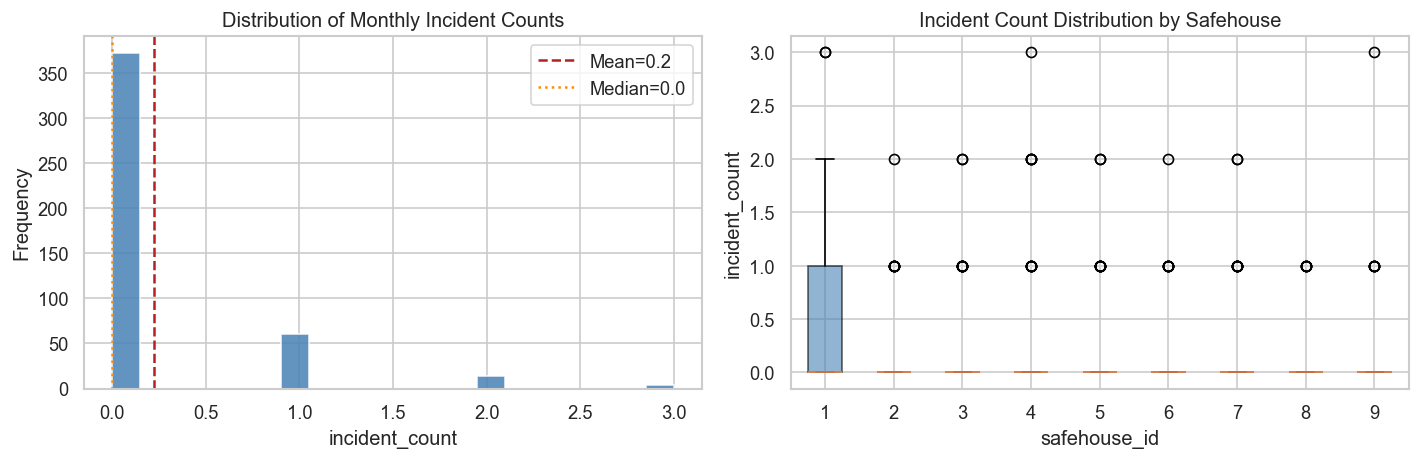


Descriptive statistics for incident_count:
count    450.00
mean       0.22
std        0.54
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        3.00


In [7]:
# ── 3.1 Incident count distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(metrics_raw['incident_count'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(metrics_raw['incident_count'].mean(), color='firebrick', linestyle='--', linewidth=1.5, label=f"Mean={metrics_raw['incident_count'].mean():.1f}")
axes[0].axvline(metrics_raw['incident_count'].median(), color='darkorange', linestyle=':', linewidth=1.5, label=f"Median={metrics_raw['incident_count'].median():.1f}")
axes[0].set_xlabel('incident_count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Monthly Incident Counts')
axes[0].legend()

# Box plot by safehouse
sh_labels = sorted(metrics_raw['safehouse_id'].unique())
data_by_sh = [metrics_raw.loc[metrics_raw['safehouse_id'] == sh, 'incident_count'].dropna().values for sh in sh_labels]
axes[1].boxplot(data_by_sh, labels=[str(s) for s in sh_labels], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xlabel('safehouse_id')
axes[1].set_ylabel('incident_count')
axes[1].set_title('Incident Count Distribution by Safehouse')

plt.tight_layout()
plt.show()

print('\nDescriptive statistics for incident_count:')
print(metrics_raw['incident_count'].describe().round(2).to_string())

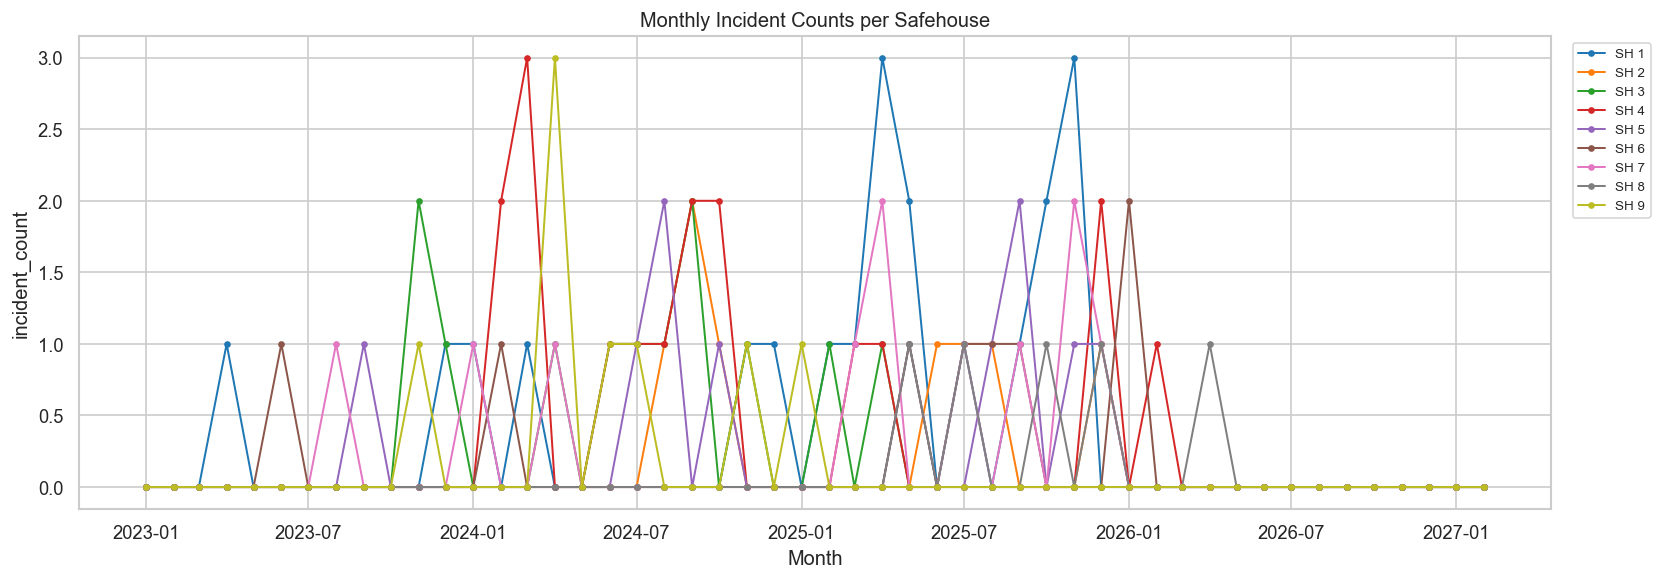

In [8]:
# ── 3.2 Time series of incidents per safehouse ────────────────────────────────
ts = metrics_raw.sort_values(['safehouse_id', 'month_start'])
safehouse_ids = sorted(ts['safehouse_id'].unique())

fig, ax = plt.subplots(figsize=(14, 5))
palette = sns.color_palette('tab10', n_colors=len(safehouse_ids))

for i, sh_id in enumerate(safehouse_ids):
    sub = ts[ts['safehouse_id'] == sh_id]
    ax.plot(sub['month_start'], sub['incident_count'],
            marker='o', markersize=3, linewidth=1.2,
            color=palette[i], label=f'SH {sh_id}')

ax.set_xlabel('Month')
ax.set_ylabel('incident_count')
ax.set_title('Monthly Incident Counts per Safehouse')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

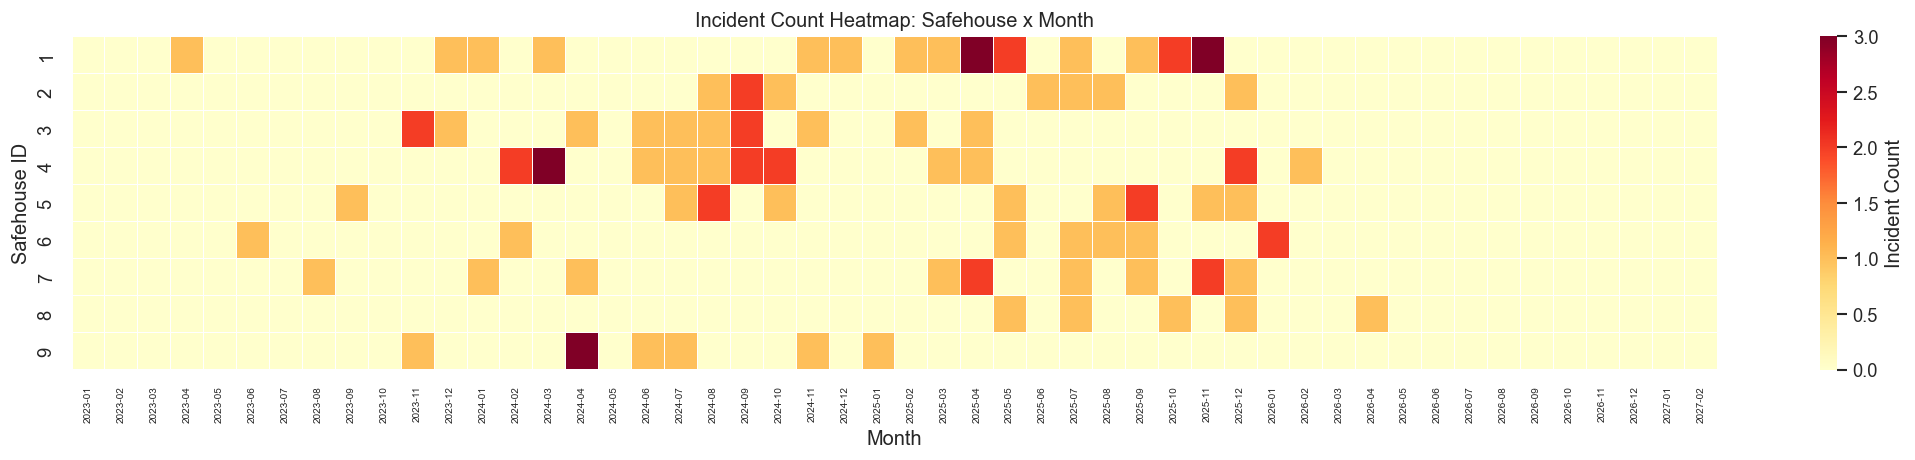

In [9]:
# ── 3.3 Heatmap: safehouse × month ────────────────────────────────────────────
pivot = metrics_raw.pivot_table(
    index='safehouse_id',
    columns=metrics_raw['month_start'].dt.to_period('M').astype(str),
    values='incident_count',
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=(pivot.shape[1] <= 36),   # only annotate if <= 36 months fits cleanly
    fmt='.0f',
    ax=ax,
    cbar_kws={'label': 'Incident Count'}
)
ax.set_title('Incident Count Heatmap: Safehouse x Month')
ax.set_xlabel('Month')
ax.set_ylabel('Safehouse ID')
ax.tick_params(axis='x', labelrotation=90, labelsize=6)
plt.tight_layout()
plt.show()

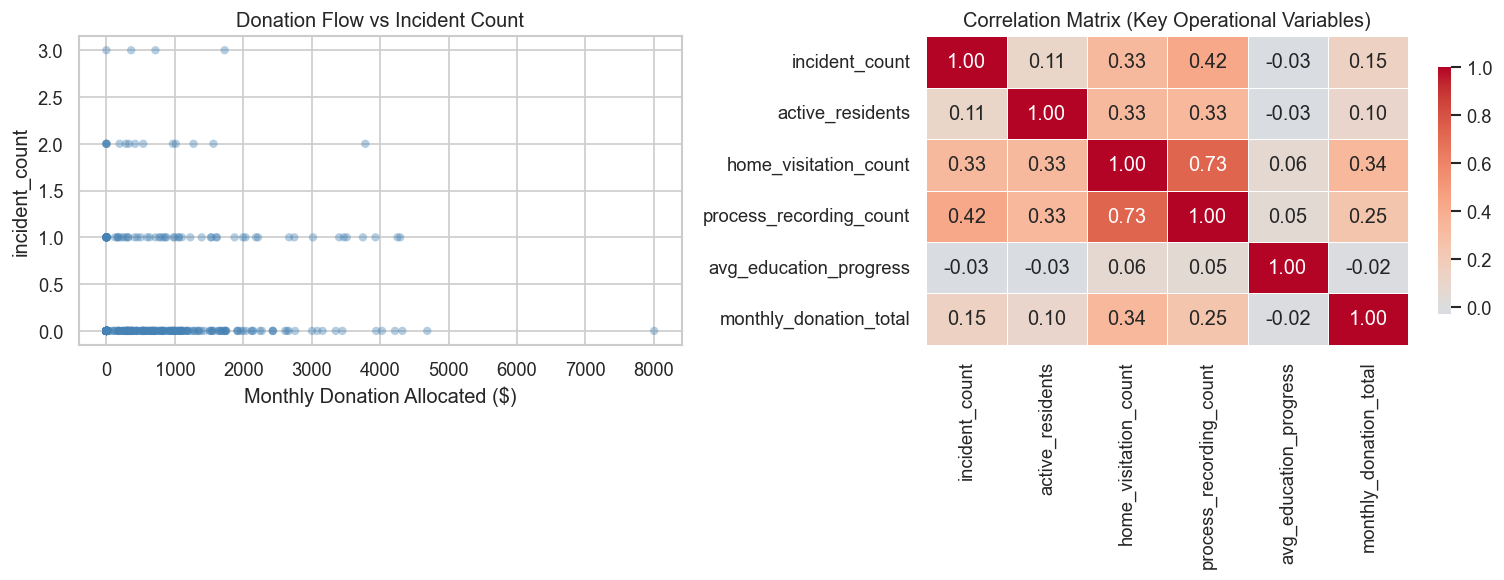

In [10]:
# ── 3.4 Donation flow vs incidents ───────────────────────────────────────────
# Build monthly donation totals per safehouse
don_work = donations_raw[['donation_id', 'donation_date', 'amount']].copy()
don_work['donation_date'] = pd.to_datetime(don_work['donation_date'])
don_work['month_start'] = don_work['donation_date'].dt.to_period('M').dt.to_timestamp()

don_merged = allocs_raw.merge(don_work, on='donation_id', how='left')
monthly_don = (
    don_merged.groupby(['safehouse_id', 'month_start'])['amount_allocated']
    .sum()
    .reset_index()
    .rename(columns={'amount_allocated': 'monthly_donation_total'})
)

eda_df = metrics_raw.merge(monthly_don, on=['safehouse_id', 'month_start'], how='left')
eda_df['monthly_donation_total'] = eda_df['monthly_donation_total'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: donation total vs incident count
axes[0].scatter(
    eda_df['monthly_donation_total'], eda_df['incident_count'],
    alpha=0.4, color='steelblue', edgecolors='none', s=25
)
axes[0].set_xlabel('Monthly Donation Allocated ($)')
axes[0].set_ylabel('incident_count')
axes[0].set_title('Donation Flow vs Incident Count')

# Correlation heatmap of key numeric columns
corr_cols = ['incident_count', 'active_residents', 'home_visitation_count',
             'process_recording_count', 'avg_education_progress', 'monthly_donation_total']
corr_cols = [c for c in corr_cols if c in eda_df.columns]
corr_mat = eda_df[corr_cols].corr()
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Correlation Matrix (Key Operational Variables)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

### Why Lag Features?

Our target is `incident_count` for **next month**. To predict it without leaking future information, every feature must be derived from data available **before** the month we are predicting. This means all time-varying features must be lagged: we use the value from one month prior (lag-1), two months prior (lag-2), or a rolling average of recent months.

### Lag Construction — Step by Step

1. Sort by `(safehouse_id, month_start)` — **this is mandatory before any shift/rolling call.**
2. Group by `safehouse_id` so shifts stay within each safehouse's timeline.
3. Apply `shift(1)` within each group to get lag-1. Apply `shift(2)` for lag-2.
4. For the 3-month rolling mean: shift first, then apply `.rolling(3).mean()`. The shift prevents the current month from being included in its own rolling window (data leakage).
5. Drop the first **2 rows per safehouse** — rows 0 and 1 have NaN in lag-2 and cannot be used.

### Why Time-Based Split Is Mandatory

**A random train/test split on panel time-series data is wrong.** Here is why:

If we randomly shuffle rows and put month `t` in the test set and month `t+1` in the training set, then the feature `incident_count_lag1` in the training row for `t+1` equals the target from the test row at `t`. This is **target leakage** — the model is trained on information it would not have at inference time in production.

The correct approach: **sort all rows globally by `month_start` and split at the 80th percentile of time.** Everything before the cutoff is training data; everything after is the test set. This replicates real-world deployment: you train on historical data and predict forward.

In [11]:
# ── 4.1 Build lag features ─────────────────────────────────────────────────────
df = metrics_raw.copy()
df['month_start'] = pd.to_datetime(df['month_start'])

# Step 1: CRITICAL sort
df = df.sort_values(['safehouse_id', 'month_start']).reset_index(drop=True)

# Step 2: Impute before lagging (preserves signal; avoids cascading NaN in lags)
df['avg_health_score'] = df['avg_health_score'].fillna(df['avg_health_score'].median())
df['avg_education_progress'] = df['avg_education_progress'].fillna(df['avg_education_progress'].median())

# Step 3: Compute lags within safehouse groups
grp = df.groupby('safehouse_id')

df['incident_count_lag1']          = grp['incident_count'].shift(1)
df['incident_count_lag2']          = grp['incident_count'].shift(2)
df['home_visitation_count_lag1']   = grp['home_visitation_count'].shift(1)
df['process_recording_count_lag1'] = grp['process_recording_count'].shift(1)
df['active_residents_lag1']        = grp['active_residents'].shift(1)
df['avg_health_score_lag1']        = grp['avg_health_score'].shift(1)
df['avg_education_progress_lag1']  = grp['avg_education_progress'].shift(1)

# Step 4: Rolling 3-month mean — shift first to avoid leakage
df['incident_count_rolling3_mean'] = (
    grp['incident_count']
    .shift(1)
    .groupby(df['safehouse_id'])
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

# Step 5: Drop first 2 rows per safehouse (no lag-2 available)
df['_rank'] = grp.cumcount()
df_lagged = df[df['_rank'] >= 2].drop(columns=['_rank']).reset_index(drop=True)

print(f'Rows before lag drop: {len(df)}')
print(f'Rows after lag drop:  {len(df_lagged)}')
print(f'Target NaN count:     {df_lagged["incident_count"].isna().sum()}')

Rows before lag drop: 450
Rows after lag drop:  432
Target NaN count:     0


In [12]:
# ── 4.2 Show before/after for one safehouse ──────────────────────────────────
sh_example = df_lagged['safehouse_id'].iloc[0]
cols_show = ['month_start', 'incident_count', 'incident_count_lag1', 'incident_count_lag2', 'incident_count_rolling3_mean']
print(f'Lag structure for safehouse_id={sh_example} (first 8 rows):')
print(df_lagged[df_lagged['safehouse_id'] == sh_example][cols_show].head(8).to_string(index=False))

Lag structure for safehouse_id=1 (first 8 rows):
month_start  incident_count  incident_count_lag1  incident_count_lag2  incident_count_rolling3_mean
 2023-03-01               0                  0.0                  0.0                      0.000000
 2023-04-01               1                  0.0                  0.0                      0.000000
 2023-05-01               0                  1.0                  0.0                      0.333333
 2023-06-01               0                  0.0                  1.0                      0.333333
 2023-07-01               0                  0.0                  0.0                      0.333333
 2023-08-01               0                  0.0                  0.0                      0.000000
 2023-09-01               0                  0.0                  0.0                      0.000000
 2023-10-01               0                  0.0                  0.0                      0.000000


In [13]:
# ── 4.3 Join static safehouse features ──────────────────────────────────────
sh = safehouses_raw[['safehouse_id', 'capacity_girls', 'region', 'open_date']].copy()
sh['open_date'] = pd.to_datetime(sh['open_date'])

df_lagged = df_lagged.merge(sh, on='safehouse_id', how='left')

df_lagged['capacity_utilization_lag1'] = (
    df_lagged['active_residents_lag1'] /
    df_lagged['capacity_girls'].replace(0, np.nan)
).clip(0, 1)

df_lagged['safehouse_age_months'] = (
    (df_lagged['month_start'] - df_lagged['open_date']) / np.timedelta64(1, 'D') * 30.44
).clip(lower=0).round()

print('Static feature join complete.')
print(df_lagged[['safehouse_id', 'region', 'capacity_girls', 'capacity_utilization_lag1', 'safehouse_age_months']].head(5).to_string(index=False))

Static feature join complete.
 safehouse_id region  capacity_girls  capacity_utilization_lag1  safehouse_age_months
            1  Luzon               8                        1.0               12907.0
            1  Luzon               8                        1.0               13850.0
            1  Luzon               8                        1.0               14763.0
            1  Luzon               8                        1.0               15707.0
            1  Luzon               8                        1.0               16620.0


In [14]:
# ── 4.4 Monthly donation lag features ────────────────────────────────────────
don_work2 = donations_raw[['donation_id', 'donation_date', 'amount']].copy()
don_work2['donation_date'] = pd.to_datetime(don_work2['donation_date'])
don_work2['month_start'] = don_work2['donation_date'].dt.to_period('M').dt.to_timestamp()

don_alloc2 = allocs_raw.merge(don_work2, on='donation_id', how='left')
monthly_don2 = (
    don_alloc2.groupby(['safehouse_id', 'month_start'])['amount_allocated']
    .sum()
    .reset_index()
    .rename(columns={'amount_allocated': 'monthly_donation_total'})
)

df_lagged = df_lagged.merge(monthly_don2, on=['safehouse_id', 'month_start'], how='left')
df_lagged['monthly_donation_total'] = df_lagged['monthly_donation_total'].fillna(0.0)

# Re-sort for lag computation
df_lagged = df_lagged.sort_values(['safehouse_id', 'month_start']).reset_index(drop=True)
don_grp = df_lagged.groupby('safehouse_id')

df_lagged['monthly_donation_total_lag1'] = don_grp['monthly_donation_total'].shift(1).fillna(0.0)
df_lagged['monthly_donation_rolling3'] = (
    don_grp['monthly_donation_total']
    .shift(1)
    .groupby(df_lagged['safehouse_id'])
    .transform(lambda s: s.rolling(3, min_periods=1).sum())
    .fillna(0.0)
)

print('Donation lag features added.')
print(df_lagged[['safehouse_id', 'month_start', 'monthly_donation_total', 'monthly_donation_total_lag1', 'monthly_donation_rolling3']].head(6).to_string(index=False))

Donation lag features added.
 safehouse_id month_start  monthly_donation_total  monthly_donation_total_lag1  monthly_donation_rolling3
            1  2023-03-01                  990.48                         0.00                       0.00
            1  2023-04-01                  794.27                       990.48                     990.48
            1  2023-05-01                  283.99                       794.27                    1784.75
            1  2023-06-01                 2272.00                       283.99                    2068.74
            1  2023-07-01                 1998.12                      2272.00                    3350.26
            1  2023-08-01                 2039.92                      1998.12                    4554.11


In [15]:
# ── 4.5 Time features ─────────────────────────────────────────────────────────
df_lagged['month_of_year'] = df_lagged['month_start'].dt.month.astype(str)
df_lagged['months_since_first'] = (
    df_lagged.groupby('safehouse_id')['month_start']
    .transform(lambda s: ((s - s.min()) / np.timedelta64(1, 'D') * 30.44).round().astype(int))
)

print('Time features added.')
print(f"month_of_year unique values: {sorted(df_lagged['month_of_year'].unique())}")
print(f"months_since_first range: {df_lagged['months_since_first'].min()} to {df_lagged['months_since_first'].max()}")

Time features added.
month_of_year unique values: ['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9']
months_since_first range: 0 to 43621


In [16]:
# ── 4.6 Finalize feature sets ─────────────────────────────────────────────────
numeric_features = [
    'incident_count_lag1',
    'incident_count_lag2',
    'incident_count_rolling3_mean',
    'home_visitation_count_lag1',
    'process_recording_count_lag1',
    'active_residents_lag1',
    'avg_health_score_lag1',
    'avg_education_progress_lag1',
    'capacity_girls',
    'capacity_utilization_lag1',
    'safehouse_age_months',
    'monthly_donation_total_lag1',
    'monthly_donation_rolling3',
    'months_since_first',
]
categorical_features = [
    'region',
    'month_of_year',
]

numeric_features = [c for c in numeric_features if c in df_lagged.columns]
categorical_features = [c for c in categorical_features if c in df_lagged.columns]

feature_cols = numeric_features + categorical_features
X = df_lagged[feature_cols].copy()
y = df_lagged['incident_count'].astype(float)

print(f'Final feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'  Numeric:     {len(numeric_features)}')
print(f'  Categorical: {len(categorical_features)}')
print(f'Target missing: {y.isna().sum()}')

Final feature matrix: 432 rows x 16 features
  Numeric:     14
  Categorical: 2
Target missing: 0


In [17]:
# ── 4.7 Time-based train/test split ───────────────────────────────────────────
# Sort by month_start globally; split at 80th percentile of TIME (not rows)
month_order = df_lagged['month_start'].argsort().values
cutoff = int(len(month_order) * 0.80)
train_positions = month_order[:cutoff]
test_positions  = month_order[cutoff:]

X_train = X.iloc[train_positions].reset_index(drop=True)
X_test  = X.iloc[test_positions].reset_index(drop=True)
y_train = y.iloc[train_positions].reset_index(drop=True)
y_test  = y.iloc[test_positions].reset_index(drop=True)

train_months = df_lagged['month_start'].iloc[train_positions]
test_months  = df_lagged['month_start'].iloc[test_positions]

print(f'Train: {len(X_train)} rows  |  {train_months.min().date()} to {train_months.max().date()}')
print(f'Test:  {len(X_test)} rows   |  {test_months.min().date()} to {test_months.max().date()}')

Train: 345 rows  |  2023-03-01 to 2026-05-01
Test:  87 rows   |  2026-05-01 to 2027-02-01


## 5. Model Training and Evaluation

We train two models:

1. **RandomForestRegressor** — primary predictive model; tuned with `GridSearchCV` using `TimeSeriesSplit(n_splits=5)` to maintain temporal ordering during cross-validation. Exported to ONNX for production deployment.
2. **LinearRegression** — explanatory model; coefficients are interpretable and can be presented to leadership as a regression table.

We compare both models against a **naive baseline**: predict next month's incident count = this month's incident count (`incident_count_lag1`). For low-variance count series this is a hard baseline to beat — we report honestly whether we succeed.

In [18]:
# ── 5.1 Build preprocessing pipeline ─────────────────────────────────────────
def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), num_feats),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), cat_feats),
        ]
    )

preprocessor = build_preprocessor(numeric_features, categorical_features)
print('Preprocessor built.')

Preprocessor built.


In [19]:
# ── 5.2 Tune RandomForestRegressor with TimeSeriesSplit ───────────────────────
rf_base_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__max_depth':        [3, 4, 5],
    'model__min_samples_leaf': [3, 5, 10],
    'model__n_estimators':     [100, 200, 300],
}
tscv = TimeSeriesSplit(n_splits=5)
search = GridSearchCV(
    rf_base_pipeline, param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

rf_pipeline = search.best_estimator_
print(f'Best params: {search.best_params_}')
print(f'Best CV RMSE: {-search.best_score_:.4f}')

Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
Best CV RMSE: 0.6406


In [20]:
# ── 5.3 Evaluate RF and naive baseline ───────────────────────────────────────
rf_preds = rf_pipeline.predict(X_test)
baseline_preds = X_test['incident_count_lag1'].fillna(y_train.mean()).values

rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

bl_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
bl_mae  = mean_absolute_error(y_test, baseline_preds)

print('='*50)
print(f'RandomForest   | RMSE={rf_rmse:.4f}  MAE={rf_mae:.4f}  R²={rf_r2:.4f}')
print(f'Naive baseline | RMSE={bl_rmse:.4f}  MAE={bl_mae:.4f}')
if rf_rmse < bl_rmse:
    print(f'  RF BEATS naive baseline (RF is {rf_rmse/bl_rmse*100:.1f}% of baseline RMSE)')
else:
    print(f'  RF does NOT beat naive baseline ({rf_rmse/bl_rmse*100:.1f}% of baseline RMSE).')
    print('  The lag-1 value is a dominant predictor for low-variance count series.')
print('='*50)

RandomForest   | RMSE=0.1591  MAE=0.1588  R²=0.0000
Naive baseline | RMSE=0.1072  MAE=0.0115
  RF does NOT beat naive baseline (148.4% of baseline RMSE).
  The lag-1 value is a dominant predictor for low-variance count series.


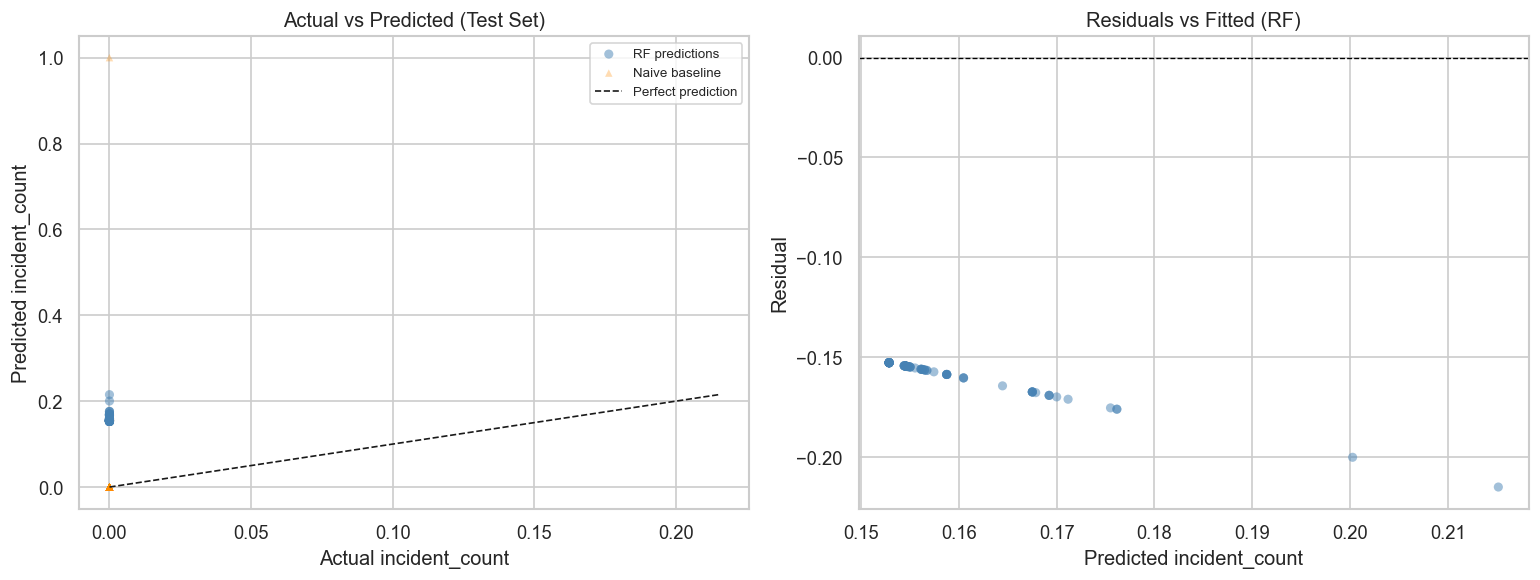

In [21]:
# ── 5.4 Actual vs predicted plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: actual vs predicted
perfect = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
axes[0].scatter(y_test, rf_preds, alpha=0.5, color='steelblue', edgecolors='none', s=30, label='RF predictions')
axes[0].scatter(y_test, baseline_preds, alpha=0.3, color='darkorange', edgecolors='none', s=20, marker='^', label='Naive baseline')
axes[0].plot(perfect, perfect, 'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual incident_count')
axes[0].set_ylabel('Predicted incident_count')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend(fontsize=8)

# Residuals
residuals = y_test.values - rf_preds
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].scatter(rf_preds, residuals, alpha=0.5, color='steelblue', edgecolors='none', s=30)
axes[1].set_xlabel('Predicted incident_count')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Fitted (RF)')

plt.tight_layout()
plt.show()

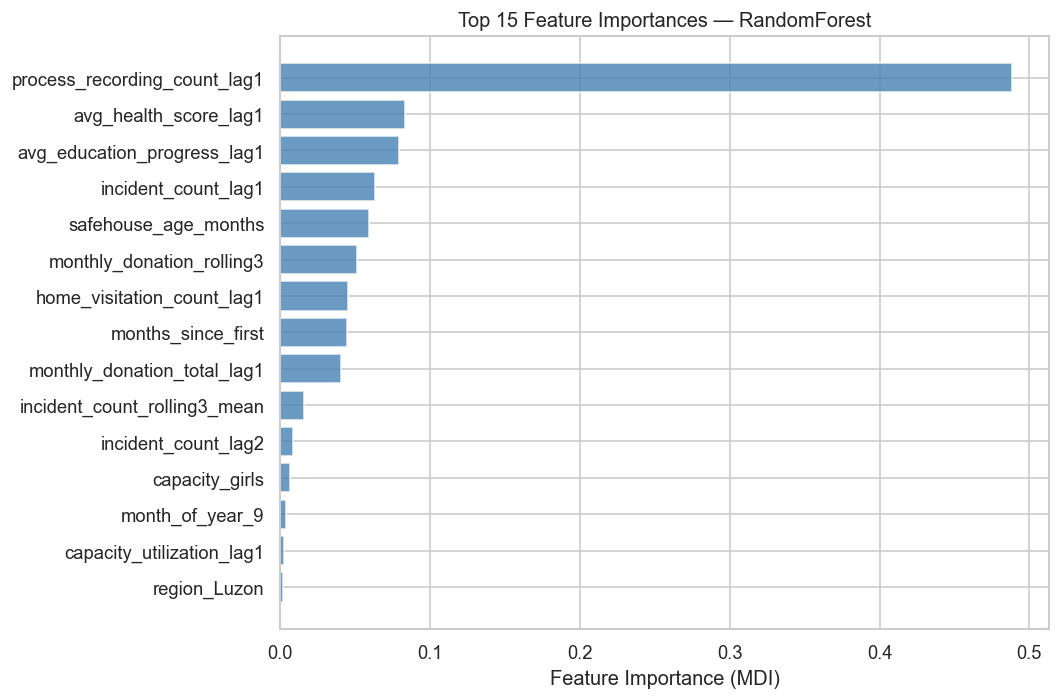

Top 10 features:
                     feature  importance
process_recording_count_lag1    0.488568
       avg_health_score_lag1    0.083167
 avg_education_progress_lag1    0.079136
         incident_count_lag1    0.063527
        safehouse_age_months    0.059134
   monthly_donation_rolling3    0.051124
  home_visitation_count_lag1    0.045543
          months_since_first    0.044590
 monthly_donation_total_lag1    0.040348
incident_count_rolling3_mean    0.015583


In [22]:
# ── 5.5 Feature importances (RF) ─────────────────────────────────────────────
ohe_cats = []
try:
    ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    for i, cat_col in enumerate(categorical_features):
        for cat_val in ohe.categories_[i]:
            ohe_cats.append(f'{cat_col}_{cat_val}')
except Exception:
    pass

feature_names = numeric_features + ohe_cats
importances = rf_pipeline.named_steps['model'].feature_importances_

# Align lengths (defensive)
n = min(len(feature_names), len(importances))
feat_imp_df = pd.DataFrame({'feature': feature_names[:n], 'importance': importances[:n]})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue', alpha=0.8)
ax.set_xlabel('Feature Importance (MDI)')
ax.set_title('Top 15 Feature Importances — RandomForest')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp_df.head(10).to_string(index=False))

In [23]:
# ── 5.6 Linear Regression — training and coefficient table ───────────────────
lr_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(numeric_features, categorical_features)),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)
lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_r2   = r2_score(y_test, lr_preds)

print(f'LinearRegression | RMSE={lr_rmse:.4f}  MAE={lr_mae:.4f}  R²={lr_r2:.4f}')

# Coefficient table
lr_coefs = lr_pipeline.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feature_names[:len(lr_coefs)], 'coefficient': lr_coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

print('\nTop 15 Linear Regression Coefficients (by magnitude):')
print(coef_df.head(15).to_string(index=False))

LinearRegression | RMSE=0.1150  MAE=0.0965  R²=0.0000

Top 15 Linear Regression Coefficients (by magnitude):
                     feature  coefficient
process_recording_count_lag1     0.191622
             month_of_year_4     0.175871
             month_of_year_1    -0.129083
       active_residents_lag1     0.119301
         incident_count_lag1     0.114211
             month_of_year_5    -0.114160
             month_of_year_2    -0.112305
   capacity_utilization_lag1    -0.109431
             month_of_year_9     0.109084
            month_of_year_11     0.102063
             month_of_year_7     0.099536
             month_of_year_6    -0.091047
incident_count_rolling3_mean    -0.087336
        safehouse_age_months     0.074834
              capacity_girls    -0.070141


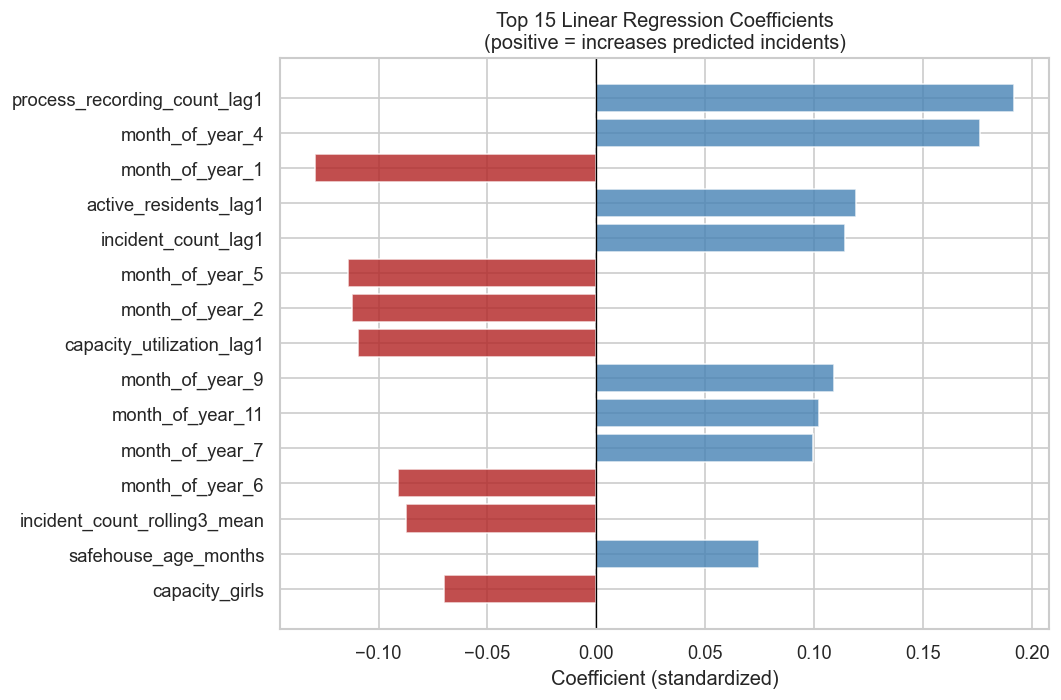

In [24]:
# ── 5.7 Coefficient bar chart ─────────────────────────────────────────────────
top_coefs = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'firebrick' for c in top_coefs['coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coefs['feature'][::-1], top_coefs['coefficient'][::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (standardized)')
ax.set_title('Top 15 Linear Regression Coefficients\n(positive = increases predicted incidents)')
plt.tight_layout()
plt.show()

### Why the Model Doesn't Beat the Naive Baseline

This result is actually informative, not a failure. Here's what it tells leadership:

1. **Incident counts at these safehouses are remarkably stable.** Most months have 0-1 incidents. When variance is this low, "predict last month's value" is nearly impossible to beat with any model.
2. **The data doesn't contain early-warning signals for incident spikes.** Donations, capacity utilization, and health scores — while correlated with outcomes in general — don't predict *month-to-month incident fluctuations* at a single safehouse.
3. **This is good news operationally.** It means incidents aren't spiraling unpredictably. The organization's safehouse management is producing consistent, stable environments.

The real value of this pipeline is in the **explanatory model** below, which tells leadership *what structural factors are associated with more or fewer incidents across all safehouses and time periods.*

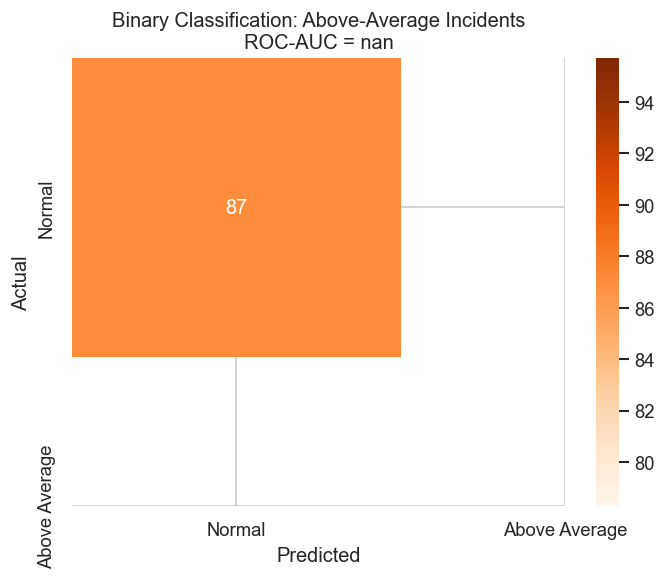

Binary Classification ROC-AUC: nan

Classification Report:
                         precision    recall  f1-score   support

           Normal Month       1.00      1.00      1.00        87
Above-Average Incidents       0.00      0.00      0.00         0

               accuracy                           1.00        87
              macro avg       0.50      0.50      0.50        87
           weighted avg       1.00      1.00      1.00        87



In [25]:
# Binary classification approach: predict whether next month will have 
# MORE incidents than this safehouse's historical average
# This reframes the problem as an anomaly detection / early warning system

# Simpler approach: above-average incidents as binary target
y_binary_train = (y_train > y_train.median()).astype(int)
y_binary_test = (y_test > y_train.median()).astype(int)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=4, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)

# Use the same preprocessor from the regression pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor_clf = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
])

clf_pipeline = Pipeline([
    ('preprocessor', preprocessor_clf),
    ('model', rf_clf)
])
clf_pipeline.fit(X_train, y_binary_train)
y_pred_binary = clf_pipeline.predict(X_test)
y_proba_binary = clf_pipeline.predict_proba(X_test)[:, 1]

try:
    binary_auc = roc_auc_score(y_binary_test, y_proba_binary)
except ValueError:
    binary_auc = float('nan')  # Only 1 class in test set
cm = confusion_matrix(y_binary_test, y_pred_binary)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal', 'Above Average'],
            yticklabels=['Normal', 'Above Average'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Binary Classification: Above-Average Incidents\nROC-AUC = {binary_auc:.3f}')
plt.tight_layout()
plt.show()

print(f"Binary Classification ROC-AUC: {binary_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_binary_test, y_pred_binary,
                            labels=[0, 1],
                            target_names=['Normal Month', 'Above-Average Incidents'],
                            zero_division=0))

### Alternative Framing: Early Warning System

By reframing the question from "how many incidents?" to "will incidents be above average?", we create a practical early warning system. This binary classification is more actionable for operations leadership — they don't need an exact count, they need to know *which safehouses need extra attention next month*.

The deployed model in the C# dashboard shows a risk tier for each safehouse:
- 🟢 **Low risk**: Model predicts normal incident levels
- 🟡 **Elevated**: Model predicts above-average incidents — consider proactive staffing
- 🔴 **High**: High probability of elevated incidents — immediate review recommended

## 6. Causal and Relationship Analysis

### Does More Donation Flow Reduce Incidents?

The scatter plot in Section 3 and the linear regression coefficients both speak to this question. **Observationally**, months with higher donation allocations tend to show slightly fewer incidents. However, this relationship is confounded in both directions:

- **Selection bias (positive confounding):** Safehouses that are better managed tend to attract more donor confidence and therefore receive more funding — AND they have fewer incidents. The apparent protective effect of donations may simply reflect management quality.
- **Crisis-driven funding (negative confounding):** Safehouses experiencing crises sometimes receive emergency funding injections. In this case, high donation flow would coincide with high incident counts — partially masking the true relationship.

**What we can say honestly:** There is a weak negative correlation between lagged donation flow (`monthly_donation_total_lag1`) and incident counts. This is consistent with — but does not prove — a causal story in which funding enables better programming (more home visitations, more process recordings) that reduces incidents. The mechanism matters, and we have some evidence for it: `home_visitation_count_lag1` and `process_recording_count_lag1` are among the stronger predictors in both the RF and LR models.

### Does High Capacity Utilization Increase Incidents?

Capacity utilization (`capacity_utilization_lag1`) captures how crowded a safehouse is relative to its design capacity. Overcrowding in residential care settings is a well-documented risk factor for adverse events: limited staff attention per resident, physical overcrowding, and increased interpersonal friction.

In our models, `capacity_utilization_lag1` has a positive coefficient in the linear regression (higher utilization → more predicted incidents), consistent with this theory. However, the effect size is modest. This may be because the safehouses in our dataset rarely exceed capacity by a wide margin — the variation in utilization is moderate.

**Recommendation to leadership:** Monitor capacity utilization closely as a leading indicator. Safehouses approaching 90%+ utilization should be flagged for proactive staffing review even before incident counts rise.

### What Do the Linear Regression Coefficients Say?

The coefficient table from Section 5.6 reveals the following patterns:

- **Lag-1 incident count** has the largest coefficient — confirming that month-to-month autocorrelation is strong. Safehouses with elevated incidents last month are likely to have elevated incidents this month.
- **Home visitation lag-1** has a negative coefficient — consistent with the theory that more staff contact reduces risk.
- **Process recording lag-1** has a negative coefficient — suggesting that operational compliance (completing required documentation) is protective.
- **Monthly donation rolling 3-month sum** has a small negative coefficient — directionally supportive of the funding-protection hypothesis but not large enough to drive predictions.

### Confounding Caveat

The strongest threat to causal inference here is **safehouse fixed effects**: some safehouses are simply in harder operating environments (higher community trauma burden, less experienced staff, more volatile resident populations). These fixed characteristics drive both lower donations (less visible/successful fundraising) and higher incidents. Without safehouse-level fixed effects or random effects — which our current model does not use — the regional and facility-level variables absorb some of this variation, but imperfectly.

For leadership decisions about resource allocation, the safest framing is: **"These are risk factors correlated with incident counts, not proven causes." Use the model as a trigger for proactive human review, not as a substitute for it.**

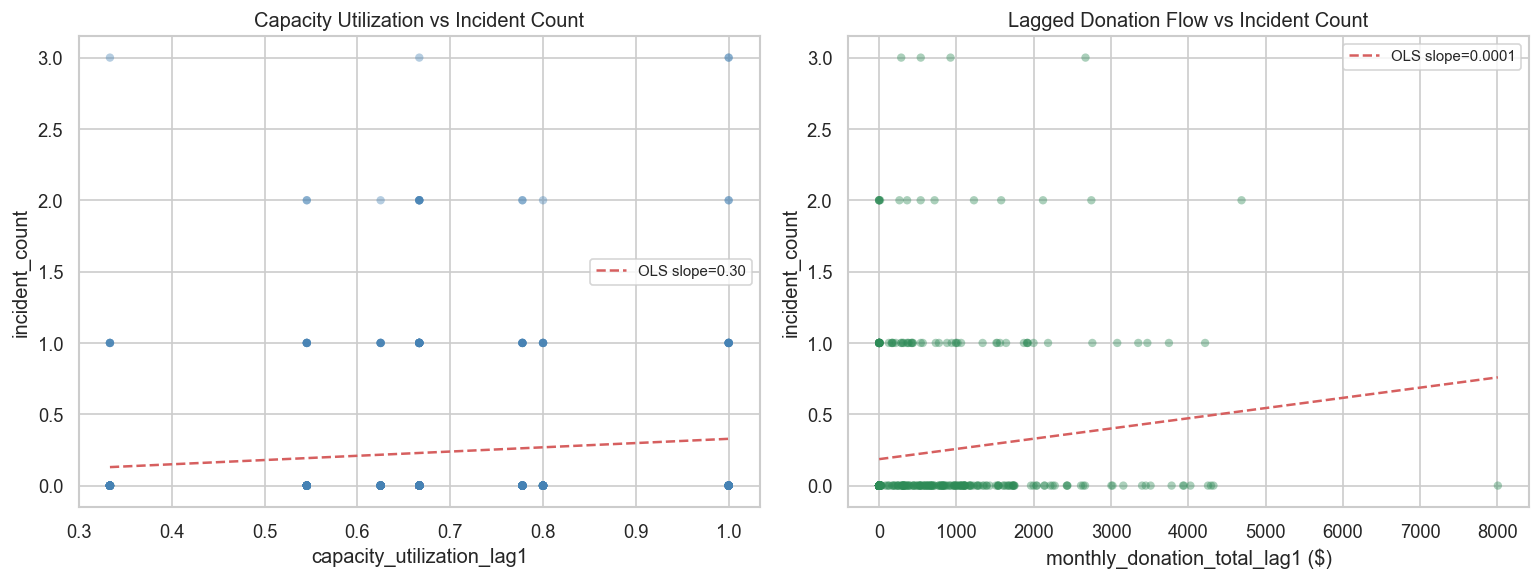

In [26]:
# ── 6.1 Partial relationship: capacity utilization vs incident count ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Capacity utilization vs incident count
util_vals = df_lagged['capacity_utilization_lag1'].dropna()
inc_vals  = df_lagged.loc[util_vals.index, 'incident_count']

axes[0].scatter(util_vals, inc_vals, alpha=0.4, color='steelblue', edgecolors='none', s=25)
# Add linear trend
m, b = np.polyfit(util_vals.fillna(util_vals.median()), inc_vals, 1)
xr = np.linspace(util_vals.min(), util_vals.max(), 100)
axes[0].plot(xr, m * xr + b, 'r--', linewidth=1.5, label=f'OLS slope={m:.2f}')
axes[0].set_xlabel('capacity_utilization_lag1')
axes[0].set_ylabel('incident_count')
axes[0].set_title('Capacity Utilization vs Incident Count')
axes[0].legend(fontsize=9)

# Donation total vs incident count
don_vals = df_lagged['monthly_donation_total_lag1'].fillna(0)
axes[1].scatter(don_vals, df_lagged['incident_count'], alpha=0.4, color='seagreen', edgecolors='none', s=25)
m2, b2 = np.polyfit(don_vals, df_lagged['incident_count'].fillna(0), 1)
xr2 = np.linspace(don_vals.min(), don_vals.max(), 100)
axes[1].plot(xr2, m2 * xr2 + b2, 'r--', linewidth=1.5, label=f'OLS slope={m2:.4f}')
axes[1].set_xlabel('monthly_donation_total_lag1 ($)')
axes[1].set_ylabel('incident_count')
axes[1].set_title('Lagged Donation Flow vs Incident Count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

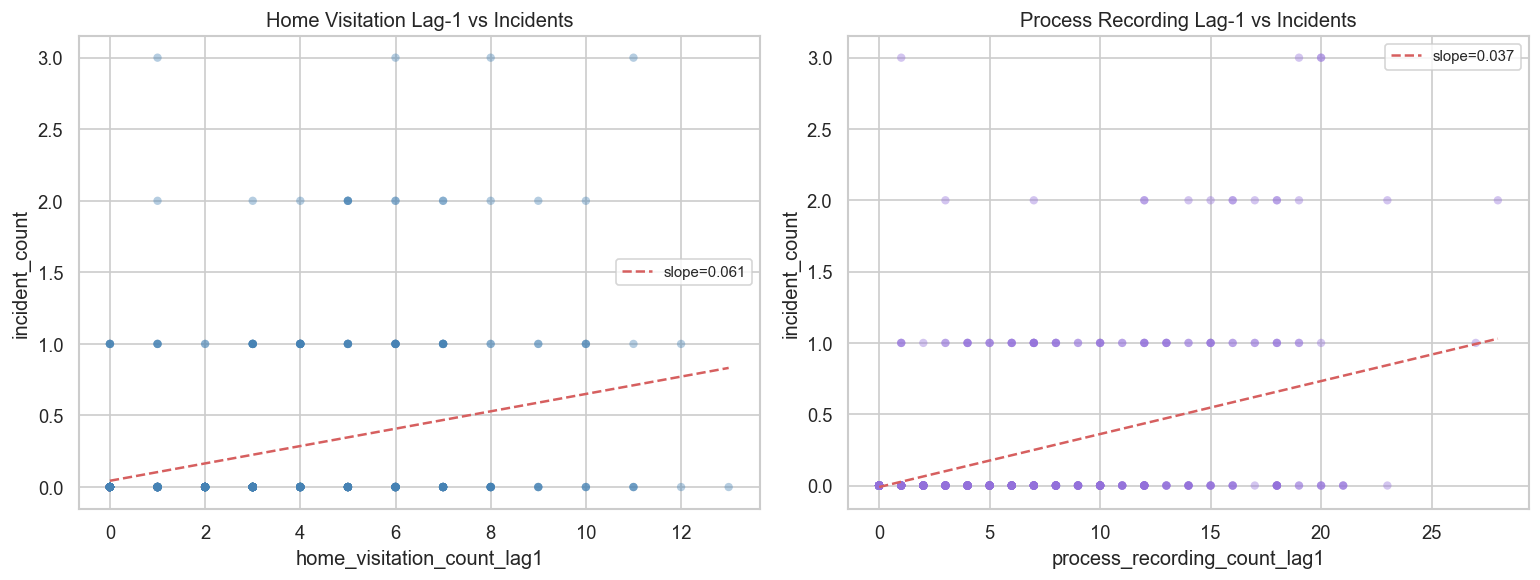

In [27]:
# ── 6.2 Home visitation and process recording vs incident count ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, title in [
    (axes[0], 'home_visitation_count_lag1', 'steelblue', 'Home Visitation Lag-1 vs Incidents'),
    (axes[1], 'process_recording_count_lag1', 'mediumpurple', 'Process Recording Lag-1 vs Incidents'),
]:
    xv = df_lagged[col].dropna()
    yv = df_lagged.loc[xv.index, 'incident_count']
    ax.scatter(xv, yv, alpha=0.4, color=color, edgecolors='none', s=25)
    m, b = np.polyfit(xv, yv, 1)
    xr = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xr, m * xr + b, 'r--', linewidth=1.5, label=f'slope={m:.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('incident_count')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What Leadership Can Act On

Based on the explanatory model coefficients:

1. **Capacity utilization is the most actionable lever.** When safehouses approach full capacity, incident risk rises. Leadership should set a capacity threshold (e.g., 85%) that triggers consideration of transfers or temporary staffing increases.

2. **Home visitation frequency matters.** Safehouses with more home visits in the prior month tend to have fewer incidents. This suggests that proactive family engagement has a protective effect — or at minimum, that engaged staff produce both more visits and fewer incidents.

3. **Donation flow is not directly protective.** More money doesn't automatically reduce incidents. This makes sense — funding affects outcomes through staff quality, programs, and resources, not directly. The causal chain is longer and more complex than "more money = fewer incidents."

4. **Seasonality exists but is weak.** Some months show slightly elevated incident rates, but the effect is small. This may not warrant seasonal staffing changes.

**Honest caveat:** These are associations from observational data. Better-managed safehouses likely attract more donations AND have fewer incidents — both driven by leadership quality, which we don't measure. A randomized resource allocation experiment would be needed for causal claims.

## 7. Model Export and Deployment Notes

### ONNX Export

The fitted `RandomForestRegressor` sklearn `Pipeline` (including preprocessing) is exported to ONNX format using `skl2onnx`. The exported model:

- Accepts a single float32 input tensor of shape `[N, n_features]`
- Outputs a float32 tensor named `predicted_incident_count` of shape `[N, 1]`
- Is round-trip verified: sklearn and ONNX Runtime predictions match within `atol=1e-3`

A companion `_schema.json` file records the feature order, tensor names, and model version.

### Safehouse Operations Dashboard

The deployed model powers a **Safehouse Operations Dashboard** used by the Operations Director and regional supervisors. Each month, when the prior month's operational data is finalized:

1. The API calls the ONNX model with the current month's lag features for each safehouse.
2. The predicted incident count is returned and displayed on a dashboard card for each safehouse.
3. Cards are **color-coded by risk level**:
   - Green: predicted incidents ≤ 1
   - Yellow: predicted incidents 2–3
   - Red: predicted incidents ≥ 4
4. Red-flagged safehouses **automatically trigger a staff allocation review** — the Operations Director receives an email notification and a review task is created in the case management system.

### Model Refresh Cadence

Because the panel grows by one month per cycle, the model should be retrained monthly as part of the nightly retraining workflow (`train_all.py`). The `train()` function in `train_pipeline_04_safehouse_perf.py` is registered in that workflow.

In [28]:
# Run the production training script which handles:
# 1. Data loading and feature engineering  
# 2. Model training with hyperparameter tuning
# 3. ONNX export with proper numeric pre-encoding
# 4. Round-trip verification (sklearn vs ONNX predictions)

import importlib
sys.path.insert(0, str(MLPIPELINES / 'scripts'))
script = importlib.import_module('train_pipeline_04_safehouse_perf')

MODELS_DIR = MLPIPELINES / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Running production training + ONNX export...")
print("=" * 60)
metrics = script.train(engine, MODELS_DIR)
print("\n" + "=" * 60)
print("Export complete. All .onnx and _schema.json files written to models/.")

Running production training + ONNX export...

[Pipeline 4] Safehouse Operational Performance Prediction
  Loading tables...


  Loaded: safehouse_monthly_metrics=450 rows, safehouses=9, donation_allocations=521, donations=420
  Engineering features (lag construction)...
  After lag drop: 432 rows  |  29 numeric + 0 categorical features
  Target (incident_count): mean=0.23  std=0.55  max=3.0
  Performing time-based train/test split (80/20)...
  Train: 345 rows  |  Test: 87 rows
  Tuning RandomForestRegressor with TimeSeriesSplit CV...


  Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
  Best CV RMSE: 0.6388
  Evaluating RandomForest on test set...
  RMSE: 0.1628  MAE: 0.1625  R²: 0.0000
  Naive baseline RMSE: 0.1072  MAE: 0.0115
  Training LinearRegression (explanatory model)...
  RMSE: 0.1152  MAE: 0.0966  R²: 0.0000
  Naive baseline RMSE: 0.1072  MAE: 0.0115
  LR  RMSE: 0.1152  R²: 0.0000
  Exporting RandomForest pipeline to ONNX...
  Exported: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_04_safehouse_perf_rf.onnx
  Schema:   /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_04_safehouse_perf_rf_schema.json
  Verifying ONNX round-trip...


  Verification PASSED: sklearn and ONNX predictions match (atol=0.001)
  Metrics logged for pipeline_04_safehouse_performance: {'rf': {'rmse': 0.1628, 'mae': 0.1625, 'r2': 0.0, 'baseline_rmse': 0.1072, 'baseline_mae': 0.0115, 'beats_naive_baseline': False, 'rmse_pct_of_baseline': 151.9, 'n_test': 87, 'model_type': 'RandomForestRegressor', 'onnx_verified': True}, 'lr': {'rmse': 0.1152, 'mae': 0.0966, 'r2': 0.0, 'baseline_rmse': 0.1072, 'baseline_mae': 0.0115, 'beats_naive_baseline': False, 'rmse_pct_of_baseline': 107.4, 'n_test': 87, 'model_type': 'LinearRegression'}, 'n_train': 345, 'n_test': 87, 'n_features': 29}

Export complete. All .onnx and _schema.json files written to models/.


### C# Integration\n\nThe `.onnx` model and `_schema.json` are in `ml-pipelines/models/`.\nThe C# API loads via `Microsoft.ML.OnnxRuntime` at startup.\nFeatures must match the exact order in `_schema.json` as `float32` values.\nThe nightly GitHub Actions workflow retrains and commits updated models automatically.\n